# Machine Learning Project – Winter 2026

## Real Estate Investment Intelligence

## Property Tier Classification & Price Prediction using Machine Learning


## **Load and Explore the Dataset**





In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

# Models
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# Remove or update imblearn import
# from imblearn.over_sampling import SMOTE
# You'll need to reinstall compatible versions - see comment below

# Linear regression
from sklearn.linear_model import LinearRegression, Lasso, LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import statsmodels.formula.api as smf
import statsmodels.api as sm

# Evaluation
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Pipeline (very important for clean ML projects)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# NOTE: To fix this issue permanently, you should reinstall compatible versions:
# pip install -U scikit-learn
# pip install -U imbalanced-learn
# Make sure both packages are compatible with each other

In [2]:
# Load dataset
df = pd.read_csv("train.csv")

# Show first 5 rows
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
print(df.duplicated().value_counts())


False    1460
Name: count, dtype: int64


In [4]:
# Shape of dataset
print("Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns.tolist())

Shape: (1460, 81)

Columns:
['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'Screen

In [5]:
# General info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [6]:
# Report missing values per column (count or percentage) in input_data

print(pd.DataFrame({'sum_missing': df.isnull().sum()}))


               sum_missing
Id                       0
MSSubClass               0
MSZoning                 0
LotFrontage            259
LotArea                  0
...                    ...
MoSold                   0
YrSold                   0
SaleType                 0
SaleCondition            0
SalePrice                0

[81 rows x 1 columns]


In [7]:
# Statistical summary of numerical columns
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


### Explain the Data's current state

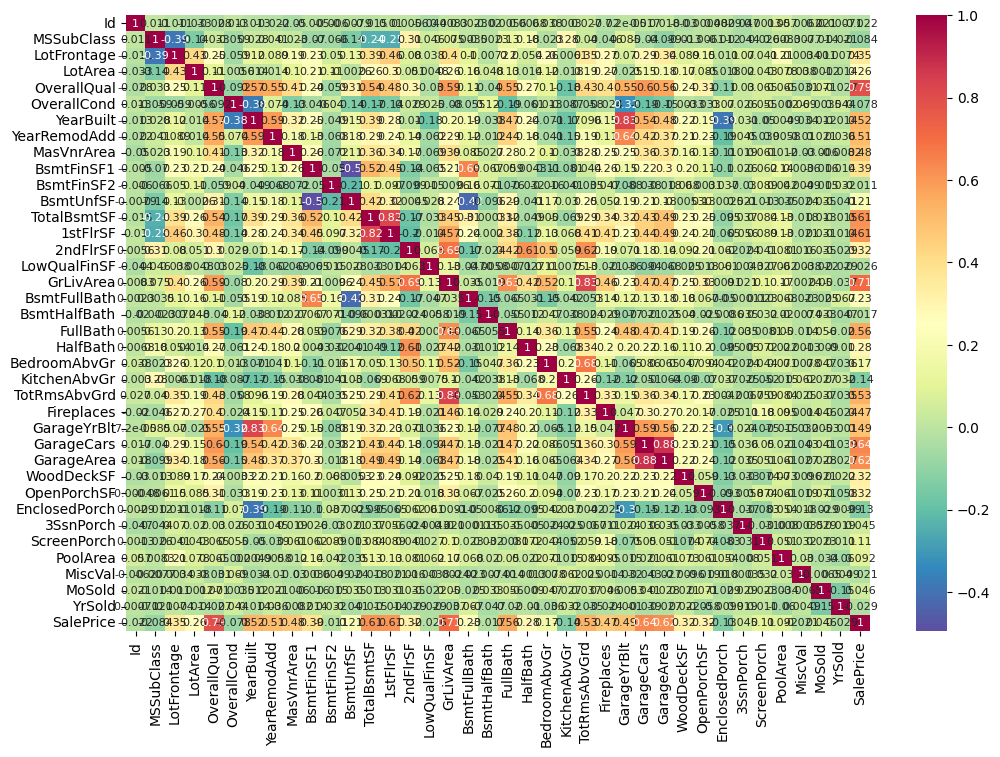

In [8]:
# Correlation heatmap

corr_matrix = df.corr(numeric_only=True)

f, ax = plt.subplots(figsize=(12, 8)) # create the figure window
sns.heatmap(corr_matrix,
            annot=True,
            annot_kws={'size': 8},
            cmap="Spectral_r");
#corr = df.corr(numeric_only=True)
#top_corr = corr['SalePrice'].abs().sort_values(ascending=False).head(10).index

#plt.figure(figsize=(10,8))
#sns.heatmap(corr.loc[top_corr, top_corr],
            #annot=True,
            #cmap='coolwarm',
            #fmt=".2f")

#plt.title("Correlation Heatmap (Top Features)")
#plt.show()


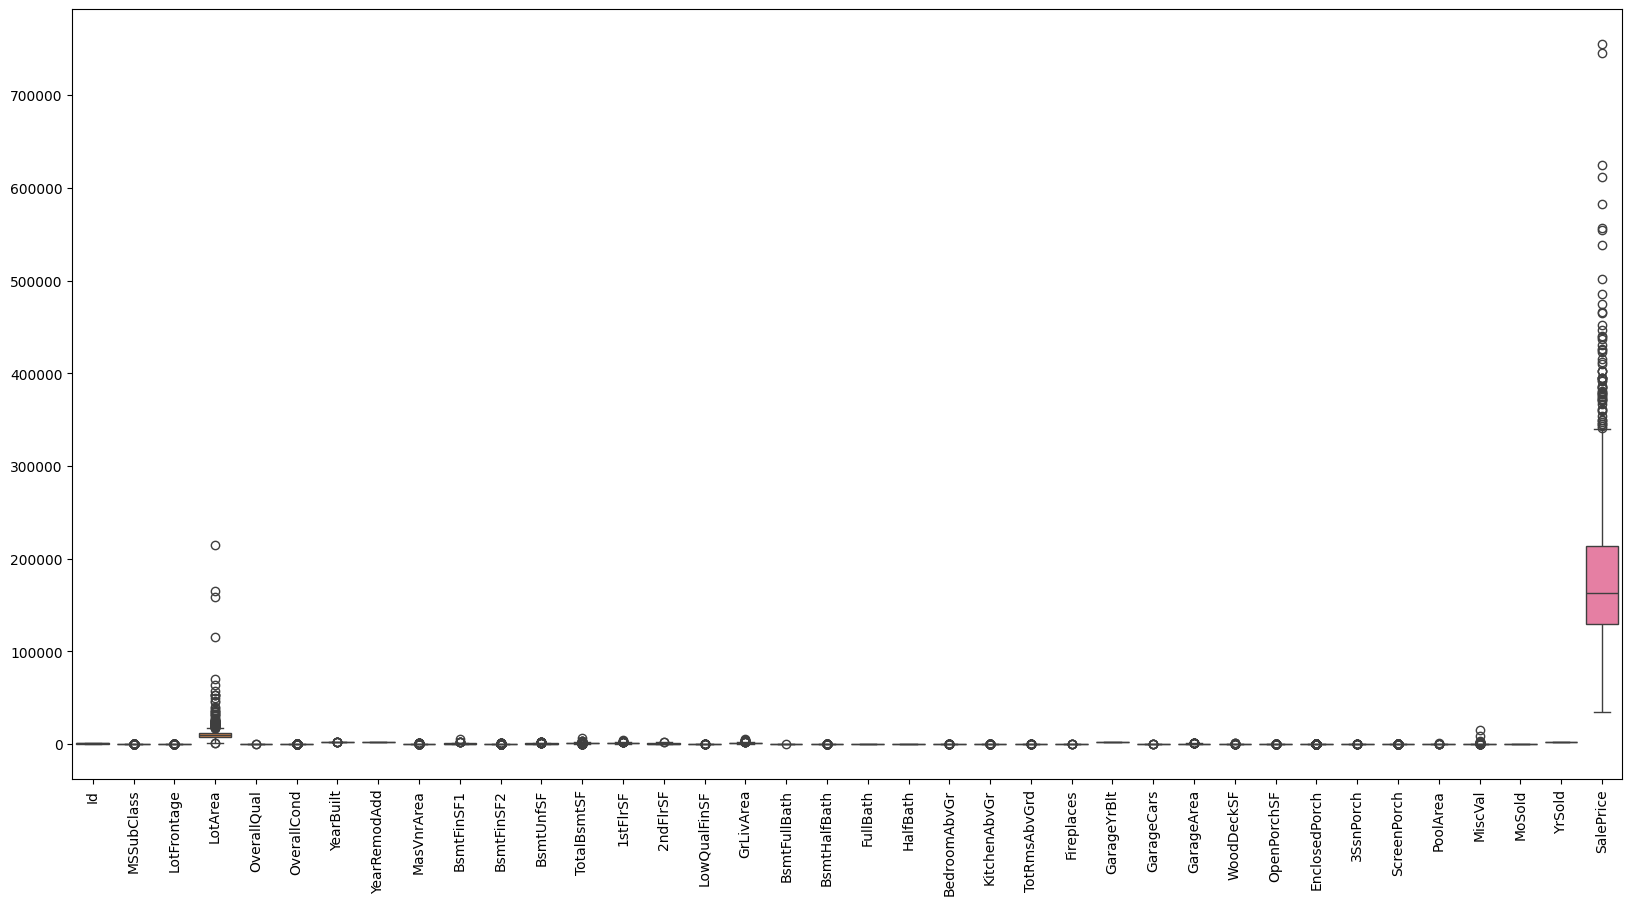

In [9]:
#Boxplot
plt.figure(figsize=(20,10))
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
sns.boxplot(data=df[num_cols])
plt.xticks(rotation=90)
plt.show()

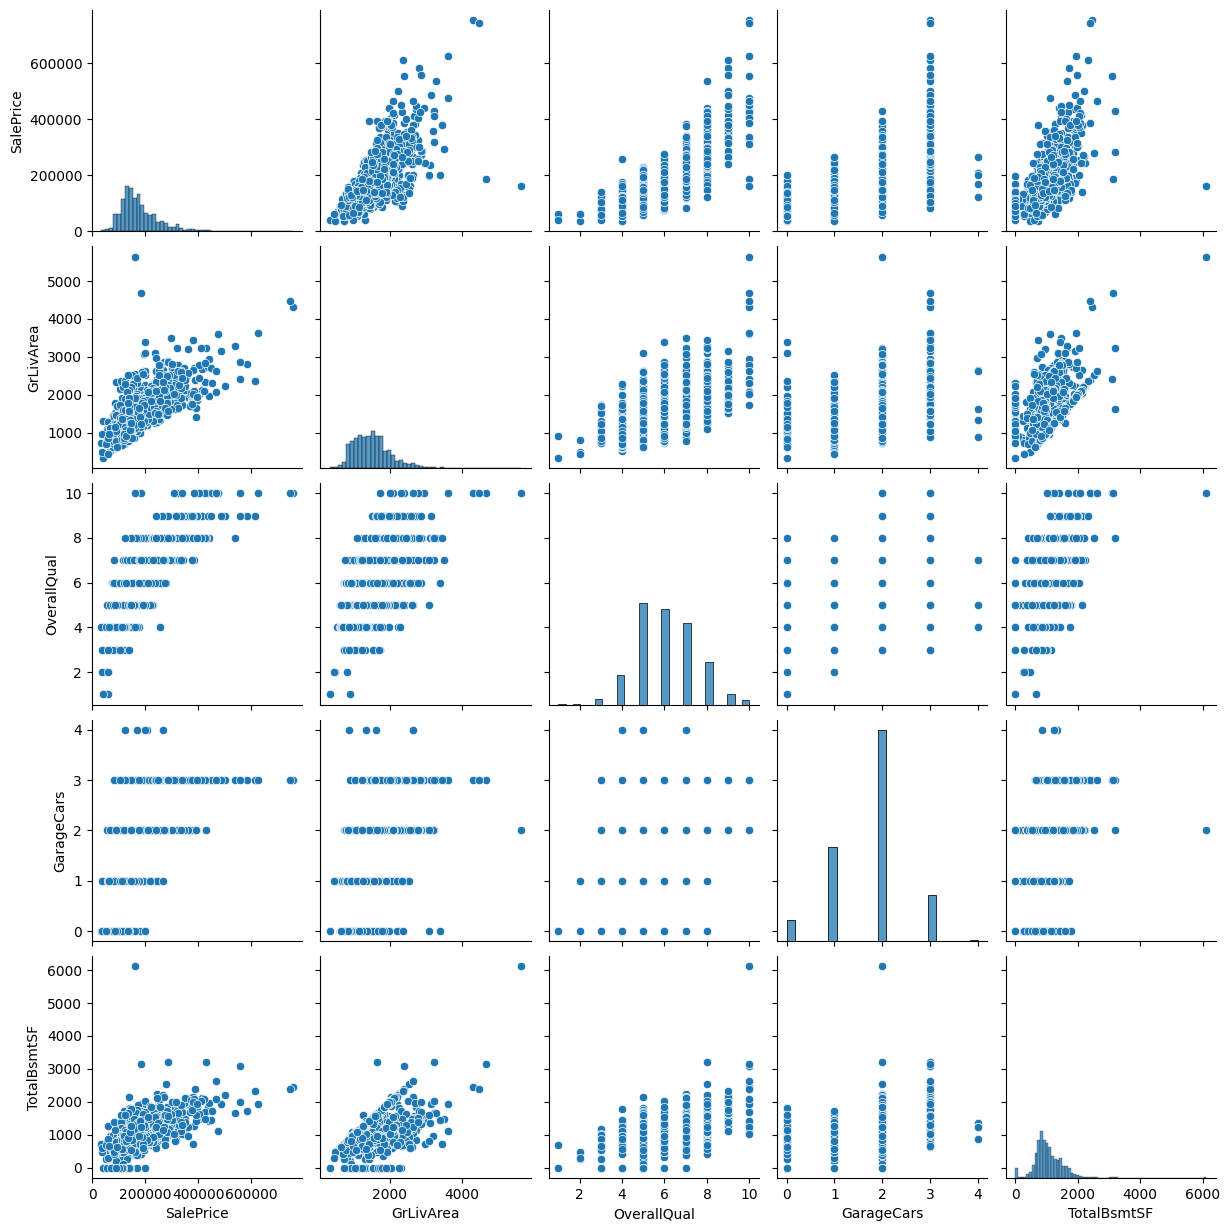

In [10]:
#Pairplot
# Select important columns
selected_cols = ['SalePrice', 'GrLivArea', 'OverallQual', 'GarageCars', 'TotalBsmtSF']

sns.pairplot(df[selected_cols])
plt.show()

##**Feature Engineering** & **Justification**

### Data Preprocessing

In [11]:
df.set_index("Id", inplace=True)
df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [12]:
# Missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64


In [13]:
# Delete the first 4 columns because of too many missing values

cols_to_drop = ["PoolQC", "MiscFeature", "Alley", "Fence"]

df = df.drop(cols_to_drop, axis=1, errors="ignore")

print(df.shape)

(1460, 76)


Note : Kepping missing values like MasVnrType (Masonry Veneer Type) or FireplaceQu(Fireplace Quality), because missing value is meaningfull(meaning there is no Masonry Veneer Type or Fireplace )

###Create a new feature

In [14]:
# Create a new feature
df['HouseAge'] = df['YrSold'] - df['YearBuilt']

df = df.drop(['YearBuilt', 'YrSold'], axis=1)

print("New feature 'HouseAge' created.")
print("Updated df shape:", df.shape)

New feature 'HouseAge' created.
Updated df shape: (1460, 75)


###Create a Classification Label
### Quantile-based binning was used to ensure balanced class distribution and avoid class imbalance issues during training.


In [15]:

print(df["SalePrice"].describe())

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


In [16]:
print(df["SalePrice"].quantile([0.25, 0.5, 0.75, 0.9]))

0.25    129975.0
0.50    163000.0
0.75    214000.0
0.90    278000.0
Name: SalePrice, dtype: float64


In [17]:
threshold = df["SalePrice"].quantile(0.75)

df["PriceCategory"] = pd.cut(
    df["SalePrice"],
    bins=[0, threshold, df["SalePrice"].max()],
    labels=["Standard", "Premium"],
    include_lowest=True
)

In [18]:
y_class=df["PriceCategory"]

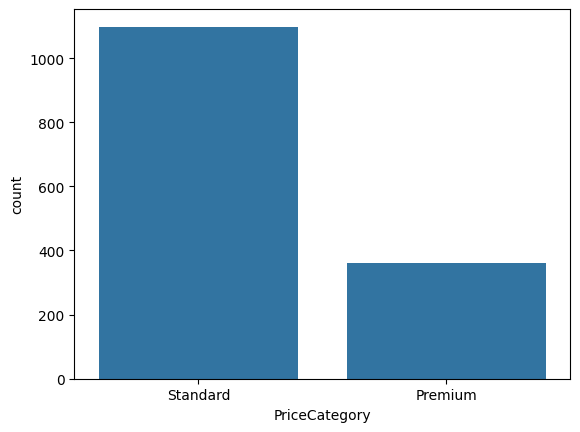

In [19]:
# Visualise the class distribution of the target variable y_class

sns.countplot(x=y_class)
plt.show()

In [20]:
# Focus on SalePrice
sale_corr = corr_matrix["SalePrice"].sort_values(ascending=False)

print(sale_corr.head(10))   # top positive correlations
print(sale_corr.tail(10))   # negative correlations

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64


##Dimensionality Reduction & Cleanup

In [21]:
# Create X set , y_class set and y_regre set

X = df.drop(["PriceCategory", "SalePrice"], axis=1)
y_class = df["PriceCategory"]   # Classification target
y_reg   = df["SalePrice"]       # Regression target

print(X.shape)
print(y_class.shape)
print(y_reg.shape)

(1460, 74)
(1460,)
(1460,)


##Imputing

###Train/Test Split

In [22]:
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X, y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

###Handle Missing Values (Imputation)

In [23]:
# Dynamically identify numerical and categorical columns to avoid KeyErrors from dropped columns
num_cols = X_train_clf.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train_clf.select_dtypes(include=['object']).columns.tolist()

# Initialize imputers
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

# Impute numerical columns
X_train_clf[num_cols] = num_imputer.fit_transform(X_train_clf[num_cols])
X_test_clf[num_cols] = num_imputer.transform(X_test_clf[num_cols])

# Impute categorical columns
X_train_clf[cat_cols] = cat_imputer.fit_transform(X_train_clf[cat_cols])
X_test_clf[cat_cols] = cat_imputer.transform(X_test_clf[cat_cols])

# Verification
print(f'Missing values in X_train_clf: {X_train_clf.isnull().sum().sum()}')
print(f'Missing values in X_test_clf: {X_test_clf.isnull().sum().sum()}')

Missing values in X_train_clf: 0
Missing values in X_test_clf: 0


###Encoding

### Encode the Dependent Variable

In [24]:
# Encode the target variable y using the LabelEncoder()
# Sanity check: print the results of y once more to ensure the transformation changes have gone through!!
# Don't worry if you get stuck in this step - you can skip it and it should probably work without any problems later on (it may deduct points)

le = LabelEncoder()

y_class = le.fit_transform(y_class)

y_class

array([1, 1, 0, ..., 0, 1, 1], shape=(1460,))

###Encode the categorical columns

In [25]:
X_train_clf = pd.get_dummies(X_train_clf, columns=cat_cols)
X_test_clf = pd.get_dummies(X_test_clf, columns=cat_cols)

# Align columns
X_train_clf, X_test_clf = X_train_clf.align(X_test_clf, join='left', axis=1, fill_value=0)
print(X_train_clf.shape)
print(X_test_clf.shape)

(1168, 267)
(292, 267)


## Outlier handling

###Columns for outlier handling were selected based on their strong business relevance to housing value according to their importance in Saleprice and their continuous numerical measurements. The approach below was used because it doesn't remove rows ( data loss ), but it caps the data.


In [26]:
cols_for_outliers = ['GrLivArea', 'GarageArea', 'TotalBsmtSF', '1stFlrSF']

Q1 = X_train_clf[cols_for_outliers].quantile(0.25)
Q3 = X_train_clf[cols_for_outliers].quantile(0.75)
IQR = Q3 - Q1

# Cap values (BEST approach)
for col in cols_for_outliers:
    lower = Q1[col] - 1.5 * IQR[col]
    upper = Q3[col] + 1.5 * IQR[col]

    X_train_clf[col] = X_train_clf[col].clip(lower, upper)
    X_test_clf[col] = X_test_clf[col].clip(lower, upper)  # use SAME bounds

###Correlation Filtering

In [27]:
# Correlation matrix (only on TRAIN)
corr_matrix = X_train_clf.corr().abs()

# Upper triangle
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Find columns to drop
to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]

# Drop from both train and test
X_train_clf = X_train_clf.drop(columns=to_drop)
X_test_clf = X_test_clf.drop(columns=to_drop)

print("Dropped features:", len(to_drop))
print("New shape:", X_train_clf.shape)

Dropped features: 12
New shape: (1168, 255)


### Scaling

Before Scaling

In [28]:
print("Before Scaling:")
print("Mean:\n", X_train_clf.mean())
print("\nStd:\n", X_train_clf.std())

Before Scaling:
Mean:
 MSSubClass                  57.448630
LotFrontage                 69.857021
LotArea                  10639.426370
OverallQual                  6.113014
OverallCond                  5.563356
                             ...     
SaleCondition_Abnorml        0.068493
SaleCondition_AdjLand        0.003425
SaleCondition_Alloca         0.006849
SaleCondition_Family         0.015411
SaleCondition_Normal         0.814212
Length: 255, dtype: float64

Std:
 MSSubClass                  43.197965
LotFrontage                 22.727270
LotArea                  10846.667345
OverallQual                  1.370231
OverallCond                  1.099705
                             ...     
SaleCondition_Abnorml        0.252698
SaleCondition_AdjLand        0.058445
SaleCondition_Alloca         0.082512
SaleCondition_Family         0.123233
SaleCondition_Normal         0.389102
Length: 255, dtype: float64


Scale

In [29]:
scaler = StandardScaler()

X_train_clf_scaled = scaler.fit_transform(X_train_clf)
X_test_clf_scaled = scaler.transform(X_test_clf)

print("Scaling complete.")
print("X_train_clf_scaled shape:", X_train_clf_scaled.shape)
print("X_test_clf_scaled shape:", X_test_clf_scaled.shape)

Scaling complete.
X_train_clf_scaled shape: (1168, 255)
X_test_clf_scaled shape: (292, 255)


This step ensures that the regression dataset uses the same preprocessed feature space (cleaned and scaled) as the classification dataset, maintaining consistency across  models

In [30]:
# Transform the scaled data to a dataframe
X_train_clf_scaled = pd.DataFrame(X_train_clf_scaled,columns=X_train_clf.columns,index=X_train_clf.index)
X_test_clf_scaled = pd.DataFrame(X_test_clf_scaled,columns=X_test_clf.columns,index=X_test_clf.index)

# Set the regression train and test data.
X_train_reg = X_train_clf_scaled.copy()
X_test_reg  = X_test_clf_scaled.copy()

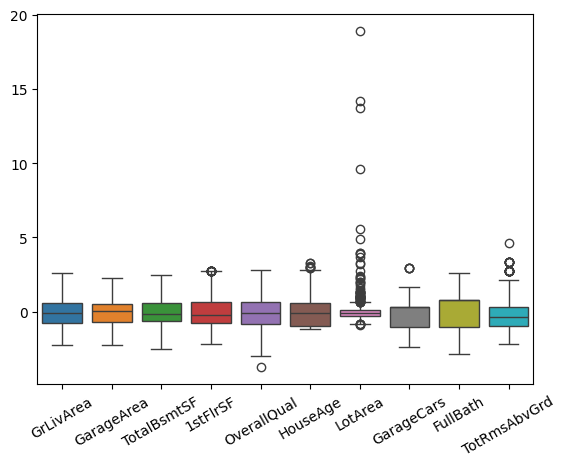

In [31]:
selected_cols = [
    'GrLivArea', 'GarageArea', 'TotalBsmtSF', '1stFlrSF',
    'OverallQual', 'HouseAge', 'LotArea',
    'GarageCars', 'FullBath', 'TotRmsAbvGrd'
]

sns.boxplot(data=X_train_clf_scaled[selected_cols])
plt.xticks(rotation=30)
plt.show()

After Scaling

In [32]:
#X_train_scaled_df = pd.DataFrame(X_train_clf_scaled, columns=X_train_clf.columns)
print("\nAfter Scaling:")
print("Mean:\n", X_train_clf_scaled.mean())
print("\nStd:\n",X_train_clf_scaled.std())


After Scaling:
Mean:
 MSSubClass              -3.269835e-17
LotFrontage             -2.570242e-16
LotArea                  7.300097e-17
OverallQual             -2.646285e-16
OverallCond              6.159457e-17
                             ...     
SaleCondition_Abnorml   -5.703200e-17
SaleCondition_AdjLand   -3.497963e-17
SaleCondition_Alloca     6.083414e-18
SaleCondition_Family    -3.041707e-18
SaleCondition_Normal     1.368768e-16
Length: 255, dtype: float64

Std:
 MSSubClass               1.000428
LotFrontage              1.000428
LotArea                  1.000428
OverallQual              1.000428
OverallCond              1.000428
                           ...   
SaleCondition_Abnorml    1.000428
SaleCondition_AdjLand    1.000428
SaleCondition_Alloca     1.000428
SaleCondition_Family     1.000428
SaleCondition_Normal     1.000428
Length: 255, dtype: float64


### Dimensionality Reduction with PCA

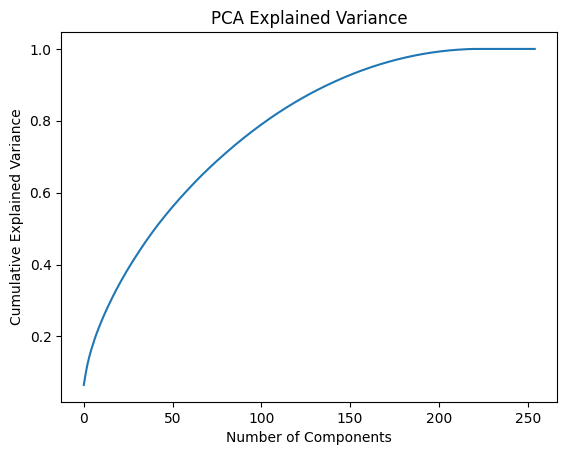

In [33]:
pca = PCA()
pca.fit(X_train_clf_scaled)

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure()
plt.plot(cumulative_variance)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.show()

In [34]:
pca = PCA(n_components=0.95)

X_train_clf_pca = pca.fit_transform(X_train_clf_scaled)
X_test_clf_pca = pca.transform(X_test_clf_scaled)

print("PCA complete.")
print("Original shape:", X_train_clf_scaled.shape)
print("Reduced shape:", X_train_clf_pca.shape)
print("Number of components kept:", pca.n_components_)

PCA complete.
Original shape: (1168, 255)
Reduced shape: (1168, 164)
Number of components kept: 164




## Machine Learning Models

First Model

 KNN Optimised (Before SMOTE)

In [35]:
# Define KNN model
knn = KNeighborsClassifier()

# Hyperparameter grid
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Grid Search for best hyperparameters. The scoring metric is f1_macro which
#is better for imbalanced datasets.
grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Train on PCA data
grid_search.fit(X_train_clf_pca, y_train_clf)

# Best model
best_knn = grid_search.best_estimator_

print("Best hyperparameters:", grid_search.best_params_)

# Predictions
y_pred_knn = best_knn.predict(X_test_clf_pca)

# Evaluation
print("Accuracy:", accuracy_score(y_test_clf, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test_clf, y_pred_knn))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_clf, y_pred_knn))

Best hyperparameters: {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'distance'}
Accuracy: 0.8698630136986302

Classification Report:
               precision    recall  f1-score   support

     Premium       0.85      0.57      0.68        72
    Standard       0.87      0.97      0.92       220

    accuracy                           0.87       292
   macro avg       0.86      0.77      0.80       292
weighted avg       0.87      0.87      0.86       292


Confusion Matrix:
 [[ 41  31]
 [  7 213]]


 SMOTE(Synthetic Minority Over-sampling Technique) is utilized , in order to treat imbalanced datasets equally.

In [36]:
!pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

#Apply SMOTE ONLY on the training set
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_clf_scaled, y_train_clf)
print("Before SMOTE:")
print(y_train_clf.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())
#  Apply PCA

pca = PCA(n_components=0.95)
X_train_clf_pca = pca.fit_transform(X_train_smote)
X_test_clf_pca = pca.transform(X_test_clf_scaled)

print("\nOriginal training shape:", X_train_clf.shape)
print("Training shape after SMOTE:", X_train_smote.shape)
print("Training shape after PCA:", X_train_clf_pca.shape)

#  Define KNN
knn = KNeighborsClassifier()

# Hyperparameter grid
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

#  Grid Search
grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

# 7. Train model
grid_search.fit(X_train_clf_pca, y_train_smote)

# 8. Best model
best_knn = grid_search.best_estimator_
print("\nBest hyperparameters:", grid_search.best_params_)

# 9. Predictions
y_pred_knn = best_knn.predict(X_test_clf_pca)

# 10. Evaluation
print("\nAccuracy:", accuracy_score(y_test_clf, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test_clf, y_pred_knn))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_clf, y_pred_knn))


Defaulting to user installation because normal site-packages is not writeable


ImportError: cannot import name '_is_pandas_df' from 'sklearn.utils.validation' (C:\Users\stamo\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py)

###Conclusion:
Premium recall went from 58% to 80%. This is a huge difference in the detection of premium sample, while accuracy slighly  improved.  

## Second Model
##Random Forest (Oprimized)

Note:We perform Random Forest using the original X_train_clf, X_test_clf, y_train_clf, y_test_clf data as
1) RF doesn't depend on distance
2) RF doesn't require scale

In [ ]:
# Define model
rf = RandomForestClassifier(random_state=42)

# Hyperparameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

# Grid Search WITHOUT PCA
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

# Train on original features
grid_search.fit(X_train_clf, y_train_clf)

# Best model
best_rf = grid_search.best_estimator_

print("Best parameters:", grid_search.best_params_)

# Predict
y_pred_rf = best_rf.predict(X_test_clf)

# Evaluate
print("Accuracy:", accuracy_score(y_test_clf, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test_clf, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_clf, y_pred_rf))

Get the feature importance from the rf classifier using rf_opt.feature_importances_
Cast it into a pd.DataFrame and use sort_values to sort by the importance
Plot the rf_opt.feature_importances_ in a barplot

In [ ]:
feature_scores = pd.DataFrame(
    best_rf.feature_importances_,
    index=X_train_clf.columns,
    columns=['Importance']
).sort_values(by='Importance', ascending=False)

print(feature_scores.head(10))

top_features = feature_scores.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y=top_features.index, data=top_features)

plt.title("Top 10 Feature Importances - Optimized Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

## **Regression Analysis**

In [ ]:
plt.figure(figsize=(15, 5))
sns.histplot(data=df, x="SalePrice", kde=True)
plt.show()

In [ ]:
print("Skewness: %f" % df['SalePrice'].skew())
print("Kurtosis: %f" % df['SalePrice'].kurt())

Investigate a relationship between a feature with (SalePrice) target variable.


In [ ]:
plt.figure(figsize=(14,6))
sns.boxplot(x='Neighborhood', y='SalePrice', data=df)

plt.xticks(rotation=45)
plt.title("Sale Price by Neighborhood")

plt.tight_layout()
plt.show()

**Prediction-Regression**

In [ ]:
regr_results = pd.DataFrame(columns=[])

**Multiple linear Regression**

In [ ]:
# Set Before
#y_reg = df["SalePrice"]
# Set the regression train and test data.
#X_train_reg = X_train_clf_scaled.copy()
#X_test_reg  = X_test_clf_scaled.copy()
#Find the corresponding y_train_reg`, y_test_reg variables
y_train_reg = y_reg.loc[X_train_reg.index]
y_test_reg  = y_reg.loc[X_test_reg.index]

In [ ]:
linear_regr = LinearRegression()
linear_regr.fit(X_train_reg, y_train_reg)

y_pred_regr = linear_regr.predict(X_test_reg)

Evaluation

In [ ]:
mae = mean_absolute_error(y_test_reg, y_pred_regr)
mse = mean_squared_error(y_test_reg, y_pred_regr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reg, y_pred_regr)

print("MAE:", round(mae, 2))
print("MSE:", round(mse, 2))
print("RMSE:", round(rmse, 2))
print("R²:", round(r2, 4))

Note: The Linear Regression model achieved an R² score of 0.875, meaning it explained 87.5% of the variability in house prices. The MAE was 17,424, indicating that the model’s predictions differed from the true prices by about $17.4k on average. The RMSE was 25,600, suggesting the presence of some larger prediction errors.

Comparison dataframe
 where you can combine/compare the actual and predicted values

In [ ]:
comparison = pd.DataFrame([])
comparison['y_actual'] = y_test_reg
comparison['y_predicted'] = y_pred_regr
comparison.head()

Visualising the results in a regplot between y_pred and y_test.


In [ ]:
plt.figure(figsize=(10,5))
sns.regplot(x= y_pred_regr, y = y_test_reg,
            scatter_kws={'color':'red',
                         'edgecolor':'blue',
                         'linewidths':0.7},
            line_kws={'color':'black','alpha':0.5}
           )
plt.xlabel('Predictions')
plt.ylabel('Overall')
plt.title("Linear Prediction")
plt.show()

In [ ]:
regr_results = pd.concat([regr_results, pd.json_normalize({'Model': 'Linear model (OLS)',
                                                           'r2':   round(r2_score(y_test_reg, y_pred_regr),3),
                                                           'RMSE': round(np.sqrt(mean_squared_error(y_test_reg, y_pred_regr)),3),
                                                           'MAE':  round(mean_absolute_error(y_test_reg, y_pred_regr),3)})])

regr_results

Coefficients and Intercept

In [ ]:
coef = pd.DataFrame({'Columns':X_train_reg.columns,
                     'Coefficient Estimate':pd.Series(linear_regr.coef_)
                    })
coef.head(10)

**Create a seaborn barplot of the coef with the top Positive and Top Negative because we have many features**

In [ ]:
# Top positive
top_pos = coef.sort_values(by='Coefficient Estimate', ascending=False).head(10)

# Top negative
top_neg = coef.sort_values(by='Coefficient Estimate').head(10)

# Combine
top_features = pd.concat([top_pos, top_neg])

plt.figure(figsize=(10,6))
sns.barplot(data=top_features, x='Coefficient Estimate', y='Columns')

plt.title("Top Positive & Negative Coefficients")
plt.show()

2nd Model : Regularization with Lasso Regression (L1 regularization) on Multiple linear Regression

In [ ]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_reg, y_train_reg)
y_pred_regr = lasso.predict(X_test_reg)

print("Training score:", lasso.score(X_train_reg, y_train_reg))
print("Testing score:",  lasso.score(X_test_reg, y_test_reg))
print("MAE of Lasso Regression:", mean_absolute_error(y_test_reg, y_pred_regr), '\n')

In [ ]:
# Putting together the lasso coefficient and their corresponding variable names in a new DF named 'coef_lasso'

coef_lasso = pd.DataFrame({"var": X_train_reg.columns,
                           "coef":lasso.coef_})

#show the dataframe
coef_lasso

**Lasso with optimal alpha using Cross-Validation in Sklearn**

In [ ]:
lassoCV_model = LassoCV(alphas=np.logspace(-3, 3, 60), cv=10, random_state=42)
lassoCV_model.fit(X_train_reg, y_train_reg)

optimal_alpha = lassoCV_model.alpha_
print(optimal_alpha)

In [ ]:
lasso_optmodel = Lasso(alpha = optimal_alpha)
lasso_optmodel.fit(X_train_reg, y_train_reg)
y_pred_opt_reg = lasso_optmodel.predict(X_test_reg)

print('r2 score (coefficient of determination): '+str(round(r2_score(y_test_reg, y_pred_opt_reg),3)))
print('RMSE : '+str(round(np.sqrt(mean_squared_error(y_test_reg, y_pred_opt_reg)),3)))
print('MAE : ' +str(round(mean_absolute_error(y_test_reg, y_pred_opt_reg),3)))

**Lasso has the ability to shrink unimportant parameters**

In [ ]:
coeffs = pd.Series(lassoCV_model.coef_, index=X_train_reg.columns)
print("Non-zero features:", (coeffs != 0).sum())

**The most influential features identified by Lasso**

In [ ]:
coeffs = pd.Series(lassoCV_model.coef_, index=X_train_reg.columns)

top_features = coeffs[coeffs != 0].sort_values(key=abs, ascending=False).head(10)

print(top_features)

In [ ]:
# Store the model performances in regr_results for the final comparison

regr_results = pd.concat([regr_results, pd.json_normalize({'Model': 'Lasso',
                                                            'r2':   round(r2_score(y_test_reg, y_pred_opt_reg),3),
                                                            'RMSE': round(np.sqrt(mean_squared_error(y_test_reg, y_pred_opt_reg)),3),
                                                            'MAE':  round(mean_absolute_error(y_test_reg, y_pred_opt_reg),3)})],
                         ignore_index=True)

regr_results

3rd Model : Non Linear model- RandomForestRegressor

In [ ]:
rr  = RandomForestRegressor(random_state=0)
rr.fit(X_train_reg, y_train_reg)
y_pred_Rf = rr.predict(X_test_reg)

print('r2 score (coefficient of determination): '+str(round(r2_score(y_test_reg, y_pred_Rf),3)))
print('RMSE : '+str(round(np.sqrt(mean_squared_error(y_test_reg, y_pred_Rf)),3)))
print('MAE : ' +str(round(mean_absolute_error(y_test_reg, y_pred_Rf),3)))

**Tuning the RandomForestRegressor**

In [ ]:
random_grid = {'n_estimators': [int(x) for x in np.linspace(10,200,10)],
               'max_depth': [int(x) for x in np.linspace(10,100,10)],
               'min_samples_split': [2,3,4,5,10],
               'min_samples_leaf':  [1,2,4,10,15,20]}

rf_random = RandomizedSearchCV(estimator = RandomForestRegressor(),
                               param_distributions = random_grid,
                               n_iter=10,
                               cv = 5,
                               n_jobs=-1)

rf_random.fit(X_train_reg,y_train_reg)
rf_random.best_params_

In [ ]:
rf_opt = rf_random.best_estimator_

# Train στο regression dataset
rf_opt.fit(X_train_reg, y_train_reg)

# Predict
y_pred_opt_Rf = rf_opt.predict(X_test_reg)

# Evaluate
print('R2:', round(r2_score(y_test_reg, y_pred_opt_Rf), 3))
print('RMSE:', round(np.sqrt(mean_squared_error(y_test_reg, y_pred_opt_Rf)), 3))
print('MAE:', round(mean_absolute_error(y_test_reg, y_pred_opt_Rf)), 3)

In [ ]:
regr_results = pd.concat([
    regr_results,
    pd.json_normalize({
        'Model': 'RF Regressor (Tuned)',
        'r2':   round(r2_score(y_test_reg, y_pred_opt_Rf), 3),
        'RMSE': round(np.sqrt(mean_squared_error(y_test_reg, y_pred_opt_Rf)), 3),
        'MAE':  round(mean_absolute_error(y_test_reg, y_pred_opt_Rf), 3)
    })
],
                         ignore_index=True)

regr_results

## **Model Explainability & AI Interpretation**

To make our model investment-ready, we must understand why it makes certain predictions, not just how accurate it is. For this reason, we use SHAP (SHapley Additive exPlanations), a widely used explainable AI technique that helps interpret machine learning models. SHAP shows how each feature contributes to an individual prediction, making the model more transparent, trustworthy, and easier to justify to business stakeholders..

##SHAP analysis for optimized Random Forest Classifier
Identify the top 3 drivers of ONE decision

In [ ]:
import shap

# Create SHAP explainer
explainer_clf = shap.TreeExplainer(best_rf)

# Compute SHAP values
shap_values_clf = explainer_clf.shap_values(X_test_clf)

# Choose one sample
sample_idx = 0
sample_data = X_test_clf.iloc[sample_idx]

# For binary classification, take class 1
shap_sample = shap_values_clf[sample_idx, :, 1]

# Create table
shap_df = pd.DataFrame({
    "Feature": X_test_clf.columns,
    "Feature Value": sample_data.values,
    "SHAP Value": shap_sample
})

# Top 3 drivers
top3 = shap_df.reindex(shap_df["SHAP Value"].abs().sort_values(ascending=False).index).head(3)

print("Top 3 drivers of this decision:")
print(top3)

# Predicted class
predicted_class = best_rf.predict(X_test_clf.iloc[[sample_idx]])[0]
print(f"\nPredicted class: {predicted_class}")

# Waterfall plot
explanation = shap.Explanation(
    values=shap_sample,
    base_values=explainer_clf.expected_value[1],
    data=sample_data.values,
    feature_names=X_test_clf.columns
)

shap.plots.waterfall(explanation, max_display=10)
plt.show()

This SHAP waterfall plot explains why the model predicted the Premium class for this specific house. The prediction starts from a baseline value (around 0.75) and is adjusted by each feature’s contribution. Key features such as OverallQual, TotalBsmtSF, and 1stFlrSF have negative contributions, pushing the prediction away from Premium. Other features like LotArea and YearRemodAdd contribute positively, slightly increasing the probability. The final output (f(x) = 0.445) reflects the combined effect of all features, resulting in a Premium classification with moderate confidence.

##SHAP Analysis of the Optimized Random Forest Model (rf_opt)




In [ ]:


# Best model
rf_opt = rf_random.best_estimator_
rf_opt.fit(X_train_reg, y_train_reg)


# SHAP explainer
explainer = shap.TreeExplainer(rf_opt)
shap_values = explainer.shap_values(X_test_reg)



In [ ]:
# Global SHAP plots
shap.summary_plot(shap_values, X_test_reg)
shap.summary_plot(shap_values, X_test_reg, plot_type="bar")



Note : The SHAP value impact on the model output  plot shows the global importance of features in predicting house prices. Features such as OverallQual, GrLivArea, and BsmtFinSF1 have the strongest impact, with higher values generally increasing the predicted price. Less important features show minimal influence, as indicated by their smaller spread around zero.

Note:The SHAP bar plot presents the global importance of features based on their average impact on the model’s predictions. OverallQual is the most influential feature, followed by GrLivArea, BsmtFinSF1, and TotalBsmtSF. Features at the bottom have minimal contribution, indicating a limited effect on the predicted house prices.


In [ ]:
# Local explanation for one house
sample_data = X_test_reg.iloc[[0]]

# Better way for waterfall plot
sample_exp = explainer(sample_data)
shap.plots.waterfall(sample_exp[0])


The plot shows how model starts from a baseline (182,190) and adjust it based on feature contributions. Feautures like OverallQual, BsmtFinSF1, and TotalBsmtSF strongly increase the predicted price, while feuteres like GarageCars and LotArea slightly decrease it. Overall, the final prediction (
285,356) is mainly driven by the strong positive impacte of OverallQual.
